In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import seaborn as sns
import time
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Embedding, Dense, Dropout,
                                     Conv1D, MaxPooling1D, LSTM,
                                     BatchNormalization, LayerNormalization,
                                     MultiHeadAttention, Add)
from tensorflow.keras import mixed_precision

2026-04-04 21:02:39.857727: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775336560.048707      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775336560.110885      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775336560.534786      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775336560.534827      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775336560.534830      55 computation_placer.cc:177] computation placer alr

In [3]:
mixed_precision.set_global_policy("mixed_float16")

print("Compute dtype :", mixed_precision.global_policy().compute_dtype)
print("Variable dtype:", mixed_precision.global_policy().variable_dtype)

Compute dtype : float16
Variable dtype: float32


In [4]:
DATASET_PATH = "/kaggle/input/datasets/dart-evall"
X = np.load(f"{DATASET_PATH}/X_sequences.npy")
y = np.load(f"{DATASET_PATH}/y_labels.npy")

with open(f"{DATASET_PATH}/kmer_vocab.pkl", "rb") as f:
    vocab = pickle.load(f)

VOCAB_SIZE = len(vocab)
SEQ_LEN    = X.shape[1]
EMBED_DIM  = 64

print(f"X shape            : {X.shape}")
print(f"Vocab size         : {VOCAB_SIZE}")
print(f"Sequence length    : {SEQ_LEN} tokens")
print(f"Class balance: True={sum(y==1):,} | Shuffled={sum(y==0):,}")

X shape            : (577200, 345)
Vocab size         : 4098
Sequence length    : 345 tokens
Class balance: True=288,600 | Shuffled=288,600


In [5]:
# Train 80% | Val 10% | Test 10%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val,  y_train, y_val  = train_test_split(X_train, y_train, test_size=0.1, random_state=42, stratify=y_train)

print(f"Train : {X_train.shape[0]:,}")
print(f"Val   : {X_val.shape[0]:,}")
print(f"Test  : {X_test.shape[0]:,}")

Train : 415,584
Val   : 46,176
Test  : 115,440


In [6]:
BATCH_SIZE = 512

def make_dataset(X, y, shuffle=False):
    dataset = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=10000, seed=42)
    dataset = dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return dataset

train_ds = make_dataset(X_train, y_train, shuffle=True)
val_ds   = make_dataset(X_val,   y_val)
test_ds  = make_dataset(X_test,  y_test)

print(f"Steps per epoch : {len(train_ds)}")
print(f"Batch size      : {BATCH_SIZE}")

I0000 00:00:1775336630.055353      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775336630.058095      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Steps per epoch : 812
Batch size      : 512


In [7]:
def transformer_encoder_block(x, embed_dim, num_heads, ff_dim, dropout_rate=0.1):
    attn_output = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(x, x)
    attn_output = Dropout(dropout_rate)(attn_output)
    x = Add()([x, attn_output])
    x = LayerNormalization()(x)

    ff = Dense(ff_dim, activation="relu")(x)
    ff = Dropout(dropout_rate)(ff)
    ff = Dense(embed_dim)(ff)
    x = Add()([x, ff])
    x = LayerNormalization()(x)

    return x

In [8]:
def build_model(vocab_size, seq_len, embed_dim=64):
    inputs = Input(shape=(seq_len,), name="kmer_input")

    # Embedding
    x = Embedding(input_dim=vocab_size, output_dim=embed_dim)(inputs)

    # Transformer Encoder
    x = transformer_encoder_block(x, embed_dim=embed_dim, num_heads=4, ff_dim=128, dropout_rate=0.1)
    x = transformer_encoder_block(x, embed_dim=embed_dim, num_heads=4, ff_dim=128, dropout_rate=0.1)

    # CNN
    x = Conv1D(filters=128, kernel_size=8, activation="relu", padding="same")(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.3)(x)

    # LSTM
    x = LSTM(64, return_sequences=False)(x)
    x = Dropout(0.3)(x)

    # Classification Head
    x = Dense(32, activation="relu")(x)
    x = Dropout(0.2)(x)
    outputs = Dense(1, activation="sigmoid", name="output", dtype="float32")(x)

    return Model(inputs, outputs)


model = build_model(vocab_size=VOCAB_SIZE, seq_len=SEQ_LEN, embed_dim=EMBED_DIM)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ kmer_input          │ (None, 345)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 345, 64)   │    262,272 │ kmer_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 345, 64)   │     66,368 │ embedding[0][0],  │
│ (MultiHeadAttentio… │                   │            │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 345, 64)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 345, 64)   │          0 │ embedding[0][0],  │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 345, 64)   │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 345, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 345, 128)  │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 345, 64)   │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 345, 64)   │          0 │ layer_normalizat… │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 345, 64)   │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 345, 64)   │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 345, 64)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 345, 64)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 345, 64)   │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 345, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 345, 128)  │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 345, 64)   │      8,256 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 345, 64)   │          0 │ layer_normalizat… │
│                     │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 546,369 (2.08 MB)

 Trainable params: 546,113 (2.08 MB)

 Non-trainable params: 256 (1.00 KB)

In [9]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

## Load Checkpoint 

In [10]:
import shutil

src = "/kaggle/input/datasets/dart-evall/latest_checkpoint.weights (1).h5"
dst = "/kaggle/working/latest_checkpoint.weights.h5"

shutil.copy(src, dst)

'/kaggle/working/latest_checkpoint.weights.h5'

In [11]:
src = "/kaggle/input/datasets/dart-evall/training_log (1).csv"
dst = "/kaggle/working/training_log.csv"

shutil.copy(src, dst)

'/kaggle/working/training_log.csv'

In [12]:
WORK_DIR        = "/kaggle/working"
BEST_MODEL_PATH = f"{WORK_DIR}/best_model.keras"
CKPT_PATH       = f"{WORK_DIR}/latest_checkpoint.weights.h5"
HISTORY_PATH    = f"{WORK_DIR}/history.pkl"
CSV_LOG_PATH    = f"{WORK_DIR}/training_log.csv"
TOTAL_EPOCHS    = 100

initial_epoch = 0

if os.path.exists(CKPT_PATH):
    print(f"[Resume] Loading weights from: {CKPT_PATH}")
    model.load_weights(CKPT_PATH)
    # Count already-completed epochs from the CSV log
    if os.path.exists(CSV_LOG_PATH):
        import csv
        with open(CSV_LOG_PATH) as f:
            initial_epoch = sum(1 for _ in csv.reader(f)) - 1  # subtract header
        print(f"[Resume] Resuming from epoch {initial_epoch}")
    else:
        print("[Resume] No CSV log found — starting epoch counter from 0")
else:
    print("[Fresh] No checkpoint found — starting training from scratch")

print(f"Epochs remaining: {TOTAL_EPOCHS - initial_epoch}")

[Resume] Loading weights from: /kaggle/working/latest_checkpoint.weights.h5
[Resume] Resuming from epoch 84
Epochs remaining: 16


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 4 variables whereas the saved optimizer has 94 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 90 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [13]:
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint,
                                         ReduceLROnPlateau, CSVLogger)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Saves the best model by val_loss
best_ckpt = ModelCheckpoint(
    BEST_MODEL_PATH,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

# Saves latest weights every epoch so training can always be resumed
latest_ckpt = ModelCheckpoint(
    CKPT_PATH,
    save_weights_only=True,   
    save_freq="epoch",
    verbose=0
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

csv_logger = CSVLogger(CSV_LOG_PATH, append=True)

print(f"Training started at: {time.strftime('%Y-%m-%d %H:%M:%S')}")
print("-" * 50)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=TOTAL_EPOCHS,
    initial_epoch=initial_epoch,     # <-- skips already-done epochs
    callbacks=[early_stop, best_ckpt, latest_ckpt, reduce_lr, csv_logger],
    verbose=1
)

print("-" * 50)
print(f"Training finished at: {time.strftime('%Y-%m-%d %H:%M:%S')}")

# Persist history so plots work across sessions
with open(HISTORY_PATH, "wb") as f:
    pickle.dump(history.history, f)
print(f"History saved to {HISTORY_PATH}")

Training started at: 2026-04-04 21:04:14
--------------------------------------------------
Epoch 85/100


I0000 00:00:1775336665.986398     127 cuda_dnn.cc:529] Loaded cuDNN version 91002


812/812 ━━━━━━━━━━━━━━━━━━━━ 0s 513ms/step - accuracy: 0.8660 - auc: 0.9427 - loss: 0.3042
Epoch 85: val_loss improved from inf to 0.33319, saving model to /kaggle/working/best_model.keras
812/812 ━━━━━━━━━━━━━━━━━━━━ 448s 535ms/step - accuracy: 0.8660 - auc: 0.9427 - loss: 0.3042 - val_accuracy: 0.8564 - val_auc: 0.9357 - val_loss: 0.3332 - learning_rate: 3.0000e-04
Epoch 86/100
812/812 ━━━━━━━━━━━━━━━━━━━━ 0s 522ms/step - accuracy: 0.8706 - auc: 0.9453 - loss: 0.2972
Epoch 86: val_loss improved from 0.33319 to 0.32300, saving model to /kaggle/working/best_model.keras
812/812 ━━━━━━━━━━━━━━━━━━━━ 441s 543ms/step - accuracy: 0.8706 - auc: 0.9453 - loss: 0.2972 - val_accuracy: 0.8576 - val_auc: 0.9362 - val_loss: 0.3230 - learning_rate: 3.0000e-04
Epoch 87/100
812/812 ━━━━━━━━━━━━━━━━━━━━ 0s 522ms/step - accuracy: 0.8720 - auc: 0.9470 - loss: 0.2927
Epoch 87: val_loss did not improve from 0.32300
812/812 ━━━━━━━━━━━━━━━━━━━━ 441s 543ms/step - accuracy: 0.8720 - auc: 0.9470 - loss: 0.292

## Plots


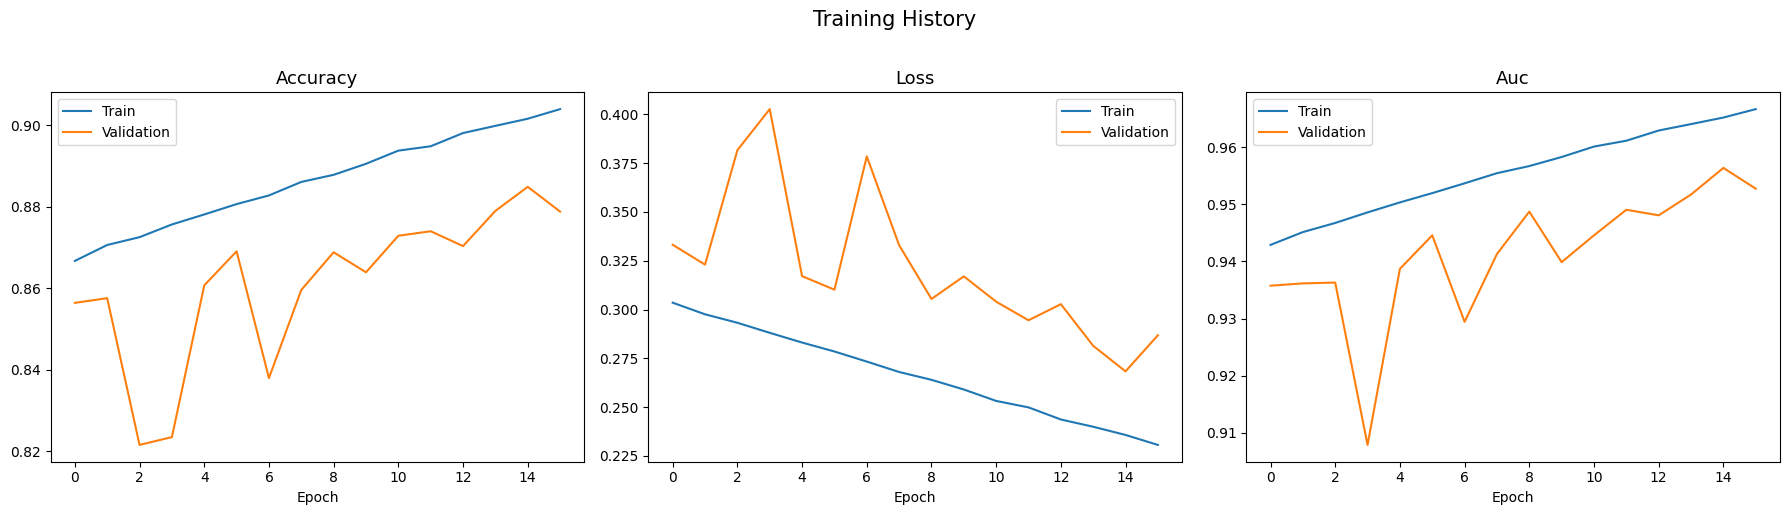

Plot saved.


In [14]:
# Load history 
with open(HISTORY_PATH, "rb") as f:
    hist = pickle.load(f)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, ["accuracy", "loss", "auc"]):
    ax.plot(hist[metric],            label="Train")
    ax.plot(hist[f"val_{metric}"],   label="Validation")
    ax.set_title(metric.capitalize(), fontsize=13)
    ax.set_xlabel("Epoch")
    ax.legend()

plt.suptitle("Training History", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(f"{WORK_DIR}/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

## Evaluation


In [15]:
model.load_weights(BEST_MODEL_PATH)

test_loss, test_acc, test_auc = model.evaluate(test_ds, verbose=0)
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test AUC      : {test_auc:.4f}")
print(f"Test Loss     : {test_loss:.4f}")

Test Accuracy : 0.8851
Test AUC      : 0.9552
Test Loss     : 0.2724


226/226 ━━━━━━━━━━━━━━━━━━━━ 43s 188ms/step
Classification Report:
              precision    recall  f1-score   support

    Shuffled       0.88      0.89      0.89     57720
        True       0.89      0.88      0.88     57720

    accuracy                           0.89    115440
   macro avg       0.89      0.89      0.89    115440
weighted avg       0.89      0.89      0.89    115440



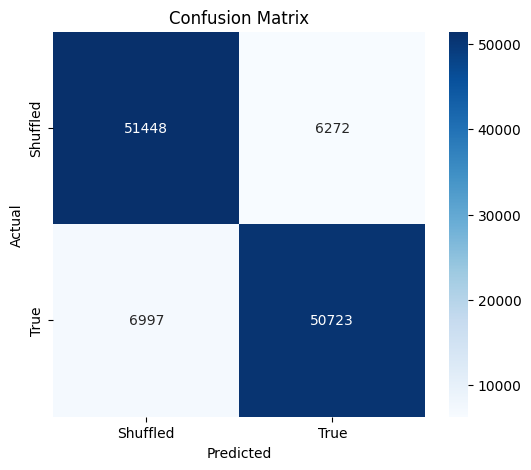

Confusion matrix saved.


In [16]:
y_pred_prob = model.predict(test_ds).flatten()
y_pred      = (y_pred_prob > 0.5).astype(int)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Shuffled", "True"]))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Shuffled", "True"],
            yticklabels=["Shuffled", "True"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig(f"{WORK_DIR}/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Confusion matrix saved.")